<div align="center">

# **LLM Visual Explorer V1**
## (PL, Aug26)

![LlmExpl — Visual Explorer](../images/LlmExpl_logo.png)

## Explorer l'espace d'un modèle de langage d'intelligence artificielle à travers un "trou de serrure"

</div>

Un mot/concept n'est pas un point isolé. Il possède une position dans un
espace sémantique de plusieurs centaines, voire milliers de dimensions.

---

### Cellules du Notebook

0. **Initialisation**

1. **Scénario**  
   Choix des concepts à explorer (de "animals" à "verbs").

2. **Embeddings**  
   Chargement du modèle et création des vecteurs sémantiques.

3. **Projection 3D + DataFrame**  
   Réduction de l'espace multidimensionnel et préparation des données.

4. **Visualisation 2D — "Carte sémantique"**  
   Exploration des concepts en 2D.

5. **Visualisation 3D — "Planétarium sémantique"**  
   Exploration des concepts en 3D.

6. **Similarités — Mesure des proximités sémantiques**  
   Classement (et archivage) des paires de concepts, du plus au moins similaire.

7. **Rapport final**  
   Synthèse et conservation des résultats de l'exploration.

8. **Messages**  
   En concluant vos explorations, avant de clore ce Notebook.


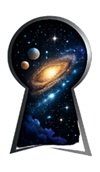

In [1]:
#=======================================================
# 0 — Initialization and required imports
#=======================================================

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from explorer.notebook_setup import *

In [2]:
#=================================================
# 1 — Scenario selection    
#=================================================

from explorer.scenarios import scenario_selector
from explorer.display import display_scenario

selection = {}

scenario_selector(
    display_function=display_scenario,
    selection=selection
)

Output()

Loading model: sentence-transformers/LaBSE


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


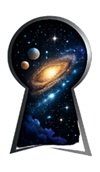

In [3]:
# ==========================================================
# 2 — Model loading and semantic vector computation
# ==========================================================

# Retrieve the selected scenario data
scenario = selection["scenario"]
concepts = selection["concepts"]
objects = selection["objects"]
icons = selection["icons"]
short_names = selection.get("short_names", {})

# Load the model and compute embeddings / semantic vectors
embeddings = compute_embeddings(concepts)

# Retrieve the loaded model
model = get_model()

# Display model information and embedding dimension
display_model(model, concept_count=len(concepts))


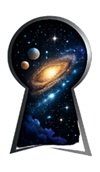

In [4]:
#================================================
# 3 — Projection from model space to 3D and DataFrame creation
#================================================
# Compute the projection
xyz, pca = compute_pca( embeddings )

# Display projection quality / fidelity (maximum = 100%)
display_projection( pca )

# Prepare data for visualization
df = create_dataframe( concepts, xyz )

In [5]:
#================================================
# 4 — 2D Semantic Map
#================================================

# This map projects concepts into a mathematical space.
# Nearby points represent concepts with similar vector representations.

fig_map = plot_map(
    df=df,
    title=tr("semantic_map_2d"),
    icons=icons,
    short_names=short_names,
    show_labels=True,
    show_icons=False,
)

fig_map.show()

In [6]:
#==============================================
# 5 — 3D Semantic Planetarium
#==============================================

fig = plot_scene(
    df=df,
    title=tr("semantic_planetarium_3d"),
    icons=icons,
    short_names=short_names,
    show_labels=True,
    show_icons=False,
)

fig.show()


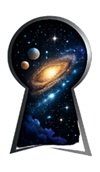


Indicative thresholds:
🟢 60–100%    High similarity
🟡 30–59%     Medium similarity
🔴 < 30%      Low similarity

NB: the similarity scale depends on the model. Values are mainly comparable
    within the same model; the ranking is more meaningful than the absolute
    value.

🟢 Top 10 semantic neighbours
--------------------------------------------------------------------------------
     1. 🇫🇷 France        ↔ 🇩🇪 Germany       ████████████         Sim: 64%  Dist: 0.4
     2. 🇫🇷 France        ↔ 🇧🇷 Brazil        ███████████          Sim: 60%  Dist: 0.3
     3. 🇯🇵 Japan         ↔ 🇨🇳 China         ███████████          Sim: 60%  Dist: 0.5
     4. 🇩🇪 Germany       ↔ 🇸🇪 Sweden        ███████████          Sim: 60%  Dist: 0.4
     5. 🇯🇵 Japan         ↔ 🇮🇳 India         ███████████          Sim: 59%  Dist: 0.3
     6. 🇨🇳 China         ↔ 🇮🇳 India         ███████████          Sim: 59%  Dist: 0.5
     7. 🇨🇳 China         ↔ 🇰🇪 Kenya         ███████████          Sim: 57%  Dist: 0.3
     8. 🇫🇷 France 

WindowsPath('explorations/countries_en/LaBSE/similarities_2026-08-26_11-19-01-173567.csv')

In [7]:
#================================================
# 6 — Similarity Ranking
#================================================

from explorer.exports import save_similarities_csv

similarities = compute_similarity(embeddings)

similarity_pairs = rank_similarity_pairs(
    concepts,
    similarities
)

display_similarity_ranking(
    similarity_pairs,
    df,
    icons,
    top_n=10,
    bottom_n=10,
)

save_similarities_csv(
    similarity_pairs,
    scenario_name=selection["scenario_name"],
    model_alias=MODEL_ALIAS,
    model_name=MODEL_NAME,
)



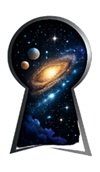


Semantic strength measures a concept’s average similarity to the core already
    formed when it is added. In comparable mode, this similarity is kept without
    normalization to support comparisons between scenarios run with the same
    model.


 1 | France        | Strength: 0.643
 2 | Germany       | Strength: 0.643
 3 | Japan         | Strength: 0.559
 4 | China         | Strength: 0.552
 5 | India         | Strength: 0.538
 6 | Brazil        | Strength: 0.519
 7 | United States | Strength: 0.499
 8 | Sweden        | Strength: 0.480
 9 | Kenya         | Strength: 0.450
10 | Egypt         | Strength: 0.422


In [8]:
# ============================================================
# 6A — Progressive Semantic Core Construction
# ============================================================

core_order, semantic_strength = build_semantic_core(
    embeddings,
    concepts,
    strength_mode=PLANETARIUM_STRENGTH_MODE,
)

display_semantic_core(
    core_order,
    semantic_strength,
    strength_mode=PLANETARIUM_STRENGTH_MODE,
)

In [9]:
# ============================================================
# 6B — Semantic-Strength Planetarium
# ============================================================

fig = plot_scene(
    df,
    title=tr("semantic_strength_planetarium"),
    icons=icons,
    short_names=short_names,
    semantic_strength=semantic_strength,
    strength_mode=PLANETARIUM_STRENGTH_MODE,
)
fig.show()


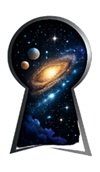


Scenario              : Countries
Exploration of the semantic space of ten countries across several continents.

Model alias           : LaBSE
Technical Model       : sentence-transformers/LaBSE
Number of concepts    : 10
Embedding dimension   : 768

----------------------------------------------------------------------
📐 PROJECTION 3D (PCA)
----------------------------------------------------------------------

768 dimensions → 3D préserve 46.2% de la structure sémantique

----------------------------------------------------------------------
🔗 OBSERVATIONS SEMANTIQUES
----------------------------------------------------------------------

🥇 Paire la plus proche : France ↔ Germany (64%)
🔻 Paire la plus éloignée : Egypt ↔ Sweden (26%)

----------------------------------------------------------------------
🚀 ALLEZ PLUS LOIN
----------------------------------------------------------------------

Une proximité ou un éloignement peut être surprenant.
Choisissez une paire qui vous intrigue

NameError: name 'create_prompt' is not defined

In [10]:
#======================================================================
# 7 — Exploration Report
#======================================================================

display_report(
    scenario=scenario,
    concepts=concepts,
    embedding_dimension=embeddings.shape[1],
    pca=pca,
    similarity_pairs=similarity_pairs,
    planetarium_figure=fig,
)


In [ ]:
# ================================================================
# 8 — Messages: Exploration Conclusion
# ================================================================

from explorer.display import display_messages

display_messages()

Output()

In [ ]:
#===================================================
# Test Cell
#===================================================

